# Ames Housing Dataset - Exploratory Data Analysis (EDA)

The objective of this notebook is to explore the Ames Housing dataset, identify missing values, and uncover relationships between our target variable (`SalePrice`) and various independent features. 

The insights gained here will directly inform our strategy for the Machine Learning Pipeline (Imputing, Scaling, Encoding, and Outlier Handling) in the subsequent modeling phase.

## 1. Importing Libraries and Initial Data Overview

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings for a professional look
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Load the dataset
df = pd.read_csv('../data/raw/train.csv')

# Initial overview 
print(f"Number of rows {df.shape[0]}")
print(f"Number of Columns {df.shape[1]}")
display(df.head())

Number of rows 1460
Number of Columns 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Target Variable Analysis: SalePrice

Assessing the distribution of housing prices is essential. In cases where the distribution exhibits a significant skew, it may be necessary to implement a logarithmic transformation to achieve normalization prior to inputting the data into our regression models.

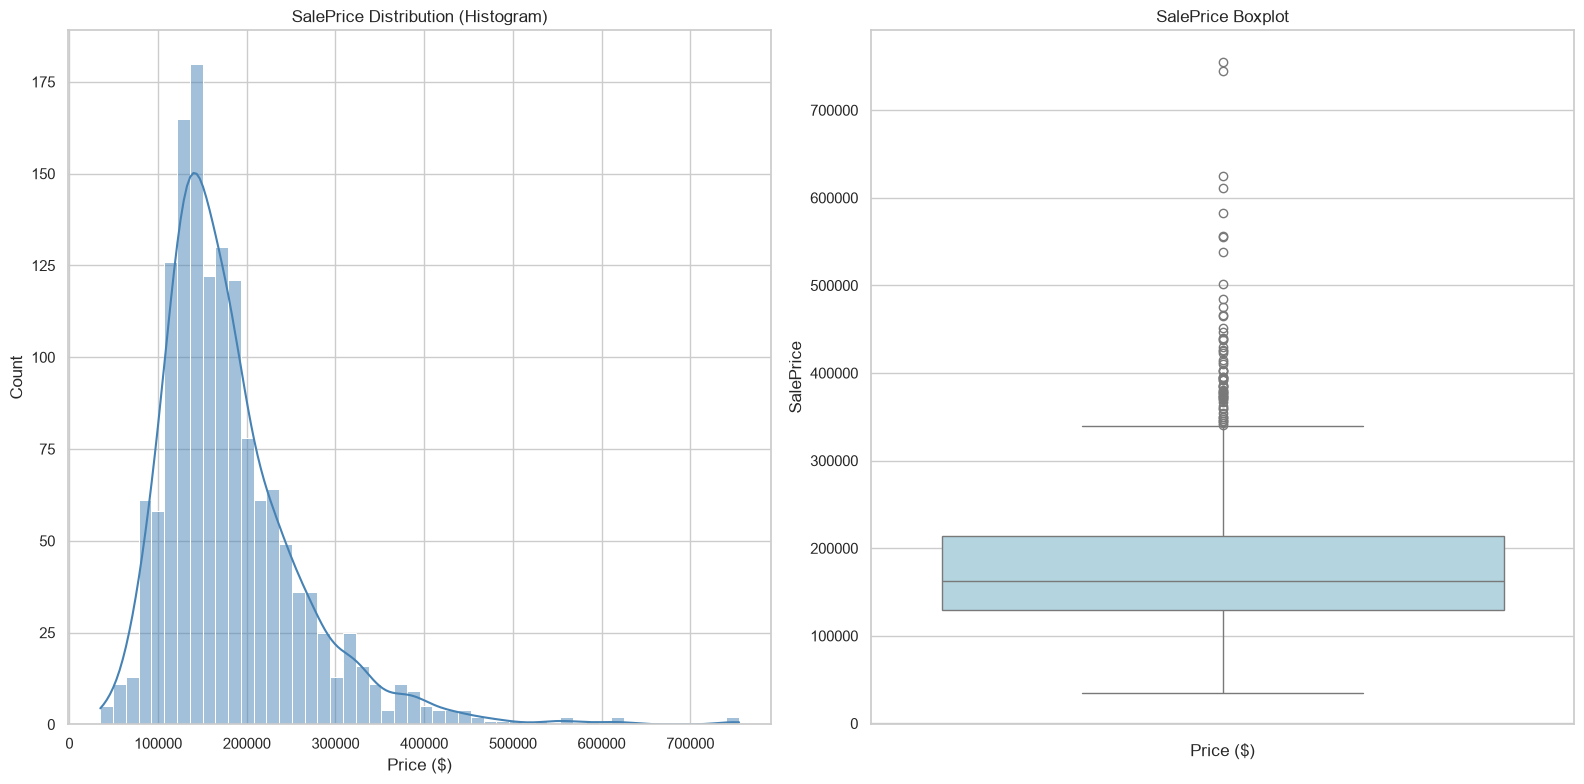

Skewness: 1.883
Note: A skewness value greater than 1 indicates a highly right-skewed distribution.


In [19]:
fig, axes = plt.subplots(1,2, figsize = (16,8))

# Histogram
sns.histplot(df["SalePrice"], kde=True, bins=50, ax= axes[0], color= "steelblue")
axes[0].set_title("SalePrice Distribution (Histogram)")
axes[0].set_xlabel('Price ($)')

# Boxplot to visualize potential outliers
sns.boxplot(df["SalePrice"], ax= axes[1], color="lightblue")
axes[1].set_title('SalePrice Boxplot')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['SalePrice'].skew():.3f}")
print("Note: A skewness value greater than 1 indicates a highly right-skewed distribution.")

As we can see above, the outliers make the graph right-skewed

## 3. Missing Values Analysis

Identifying which columns contain missing data and their respective missing ratios is essential for selecting the appropriate imputation strategies in our Scikit-Learn Pipeline.

In [21]:
# Calculate missing data percentages
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# Display as a styled DataFrame
missing_df = pd.DataFrame({'Missing Ratio (%)': missing_data})
display(missing_df.head(15).style.background_gradient(cmap='Reds'))

,Missing Ratio (%)
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


## 4. Numerical Features vs. SalePrice (Bivariate Analysis)

We will use scatter plots to observe the linear or non-linear relationships between the target variable and key numerical features. This step is also crucial for spotting extreme outliers that might negatively impact model performance.

In [34]:
# Checking the numeric columns corrolated with SalePrice
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

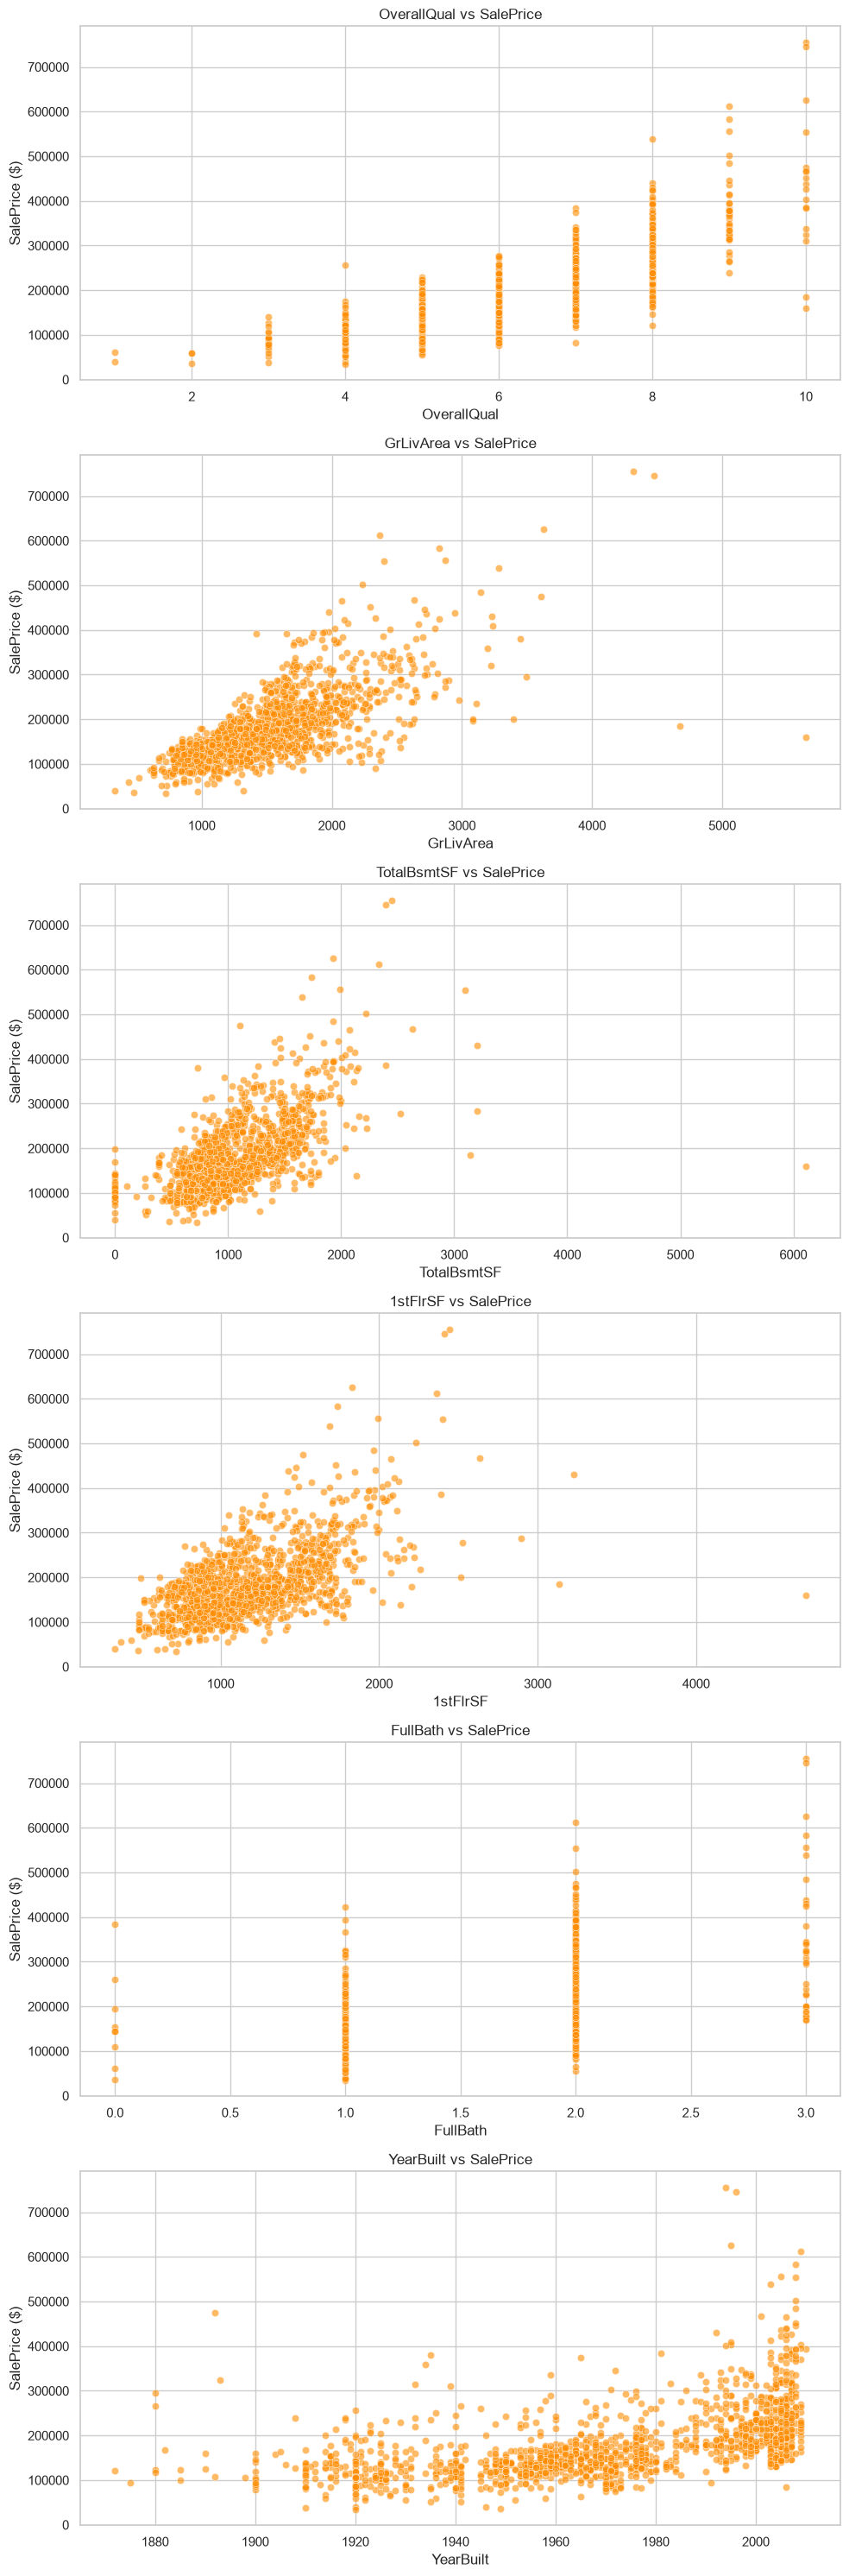

In [ ]:
# Select a few key numerical features to investigate
num_features = ["OverallQual","GrLivArea","TotalBsmtSF","1stFlrSF","FullBath","YearBuilt"]

fig, axes = plt.subplots(len(num_features), 1, figsize=(10, 5 * len(num_features)))

for i, col in enumerate(num_features):
    sns.scatterplot(data=df, x=col, y='SalePrice', ax=axes[i], alpha=0.6, color='darkorange')
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].set_ylabel('SalePrice ($)')
    
plt.tight_layout()
plt.show()

The correlation analysis revealed that the selected variables are positively correlated with SalePrice. An examination of the scatter plots showed that the overall trend is consistent with the correlation results, although there are some notable outliers in certain observations.

## 5. Categorical Features vs. SalePrice

Tree-based models (like Random Forest and XGBoost) handle categorical splits exceptionally well. We will use boxplots to see how different categories (e.g., overall quality, neighborhood) impact the variance in housing prices.

In [ ]:
# List categorical columns
cat_cols = df.select_dtypes(include="object").columns
print(cat_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\489604010.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


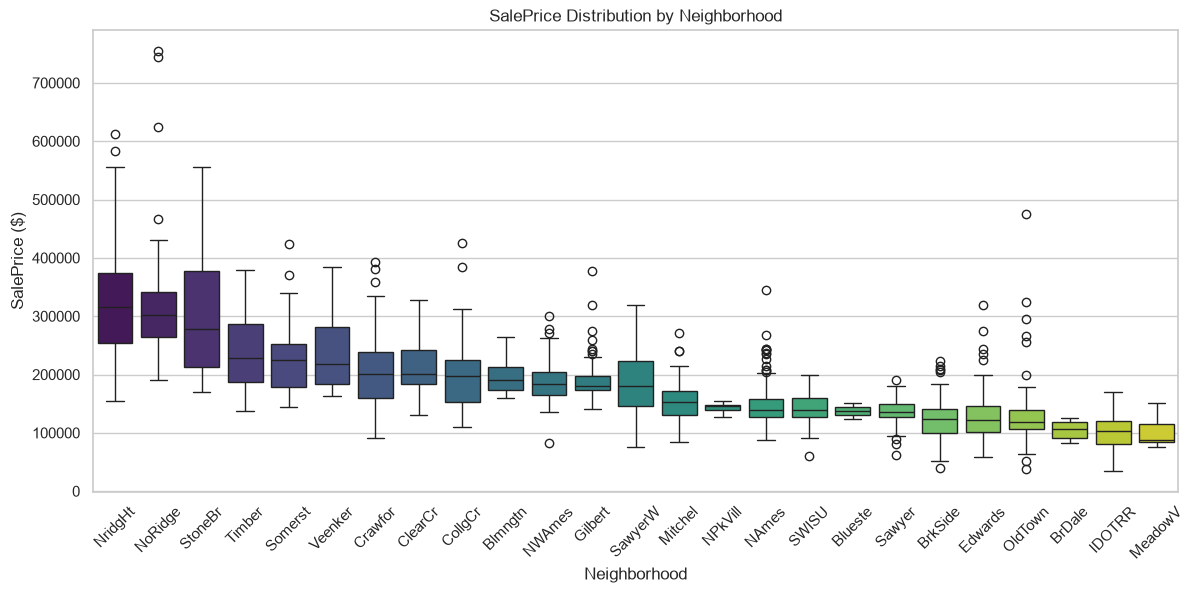

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


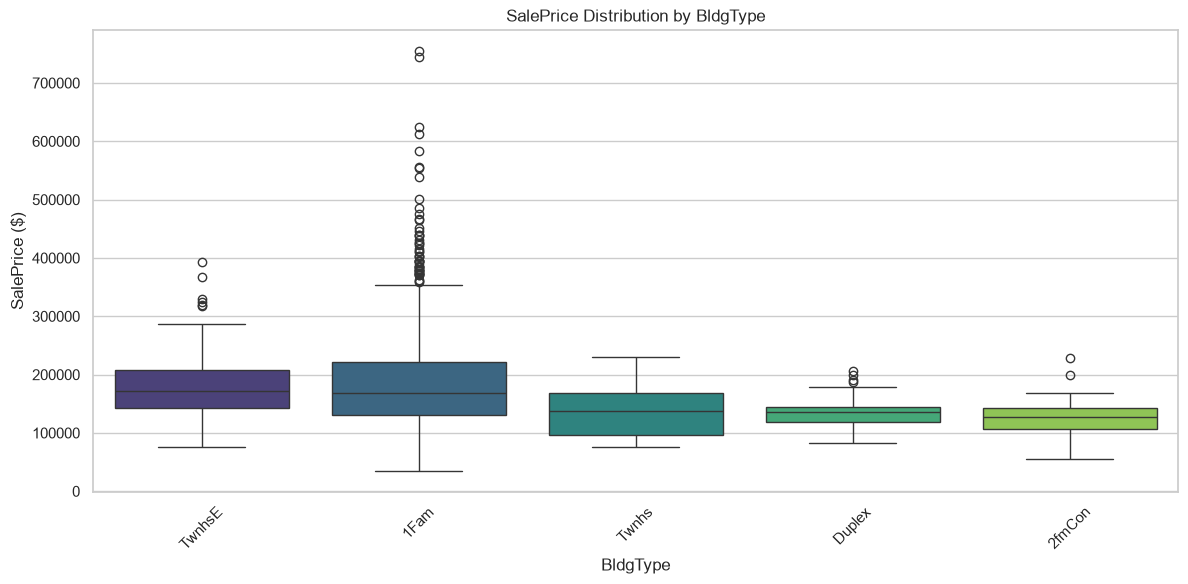

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


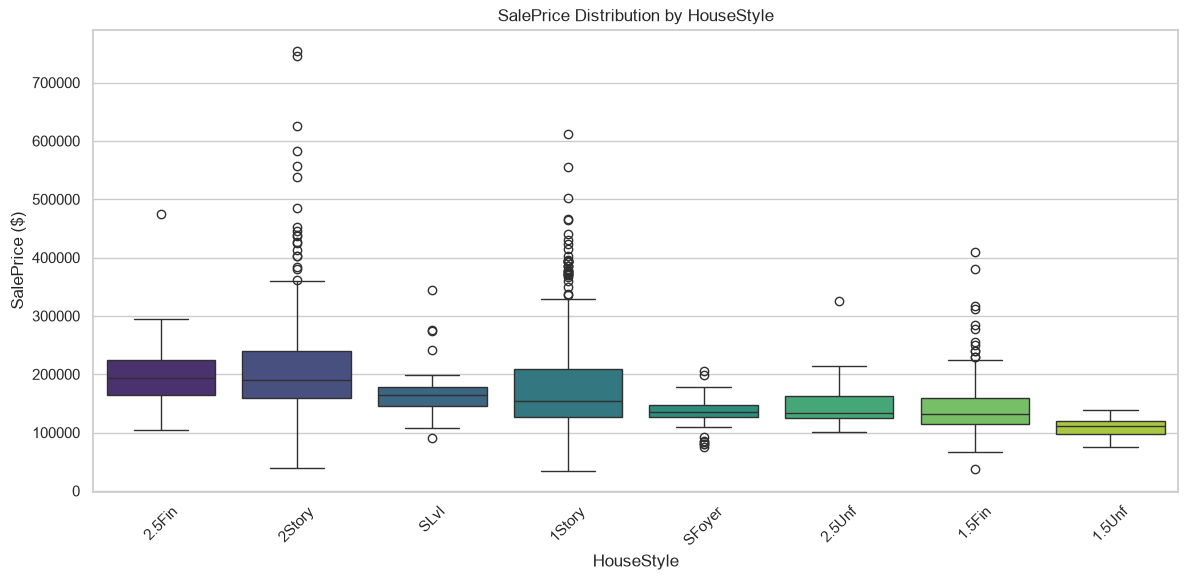

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


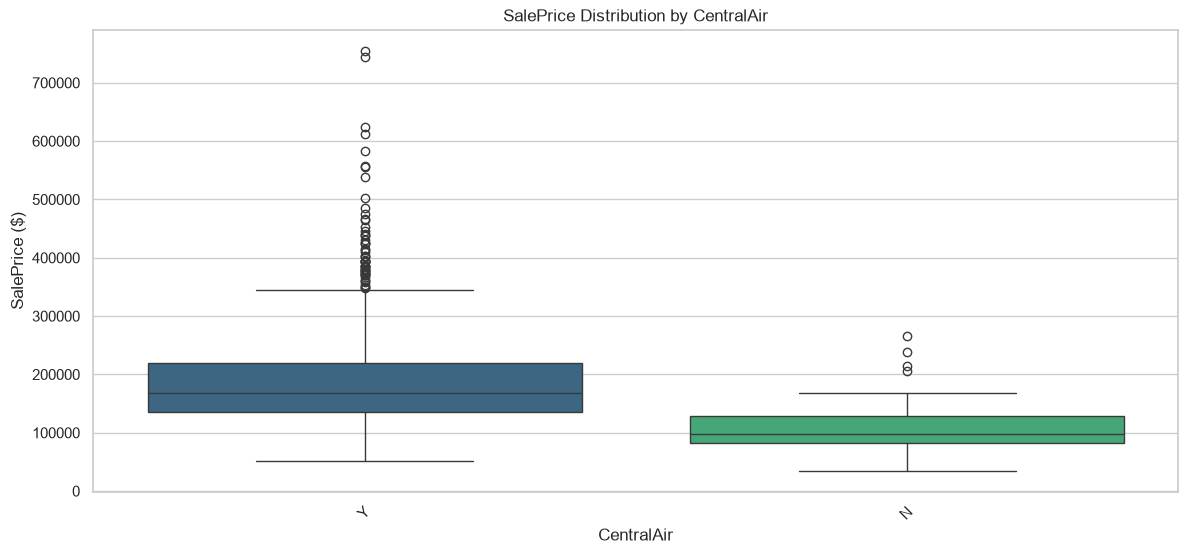

C:\Users\Tolga\AppData\Local\Temp\ipykernel_23532\1774731758.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')


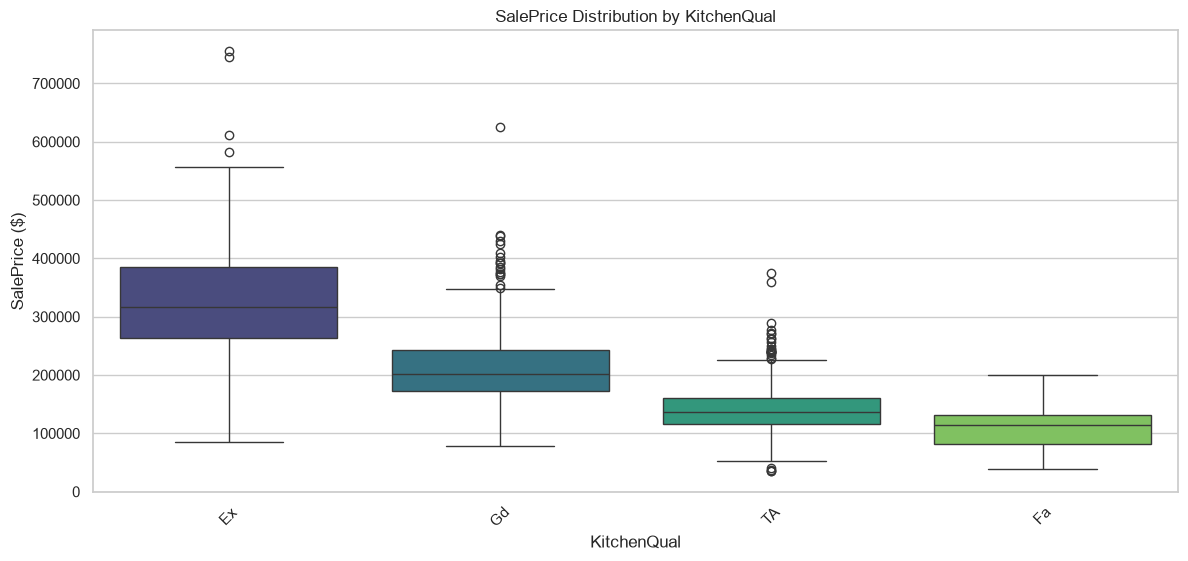

In [39]:
# Select key categorical or ordinal features to investigate
cat_features = ['Neighborhood', 'BldgType','HouseStyle','CentralAir','KitchenQual']

for col in cat_features:
    plt.figure(figsize=(14, 6))
    
    # Sort categories by median SalePrice for better readability
    sorted_order = df.groupby(col)['SalePrice'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df, x=col, y='SalePrice', order=sorted_order, palette='viridis')
    plt.title(f'SalePrice Distribution by {col}')
    plt.xticks(rotation=45)
    plt.ylabel('SalePrice ($)')
    plt.show()

It can be seen that as the quality level increases, the median SalePrice rises. In addition, it is observed that in some high-quality categories, the price distribution is broader that is, home prices show greater variability within those categories.

Also; across almost all categorical features, outliers are heavily concentrated at the higher end of the price spectrum, with very few appearing on the lower end. This is a classic characteristic of real estate markets. While housing prices have a strict lower bound dictated by basic land and construction costs, there is practically no upper limit for luxury materials, massive lot sizes, or premium locations. This naturally creates a right-skewed distribution where extreme deviations stretch upward. Since we are building a pipeline with tree-based models, these extreme values will be handled effectively without the need for truncation or removal.